**Author:** Filip Křikava, Institute of Biophysics of the Czech Academy of Sciences / Masaryk University
**Version:** 1.0.0 · **License:** MIT · Copyright (c) 2026 Institute of Biophysics of the Czech Academy of Sciences
**Citation:** see `CITATION.cff`

# Stopped-flow CD kinetic analysis of G-quadruplex folding

Fits averaged stopped-flow circular dichroism (CD) kinetic traces (Chirascan export) with one-, two- and
three-exponential models (association / decay), reports the fitted parameters with 95 % confidence intervals,
goodness-of-fit statistics (R², RMSD, AIC, BIC, Durbin-Watson), residual plots and an F-test for nested-model
comparison (1 vs 2 and 2 vs 3 exponentials), and exports everything to a single Excel sheet.

**Workflow** (run the cells top to bottom)
1. Set `directory` and load the raw CSV files (metadata + kinetic traces).
2. Select and average the chosen traces (`mean_df`), remove dead-time points (`trimmed_df`).
3. Subtract the baseline and convert the CD signal (mdeg) to Δε (`kinetics_df`). The optical path lengths of the
   absorbance and of the CD measurement can be set (default: 1 cm for the absorbance; the CD path length is read from
   the CSV header).
4. Fit the models. Every fit is stored in `fit_results` under the model name, so fits do not overwrite each other.
5. Compare nested models with an F-test (1 vs 2 and 2 vs 3 exponentials).
6. Export: set `MODEL_TO_EXPORT` and run the export cell. It refuses to export a fit that was made on different data
   than the current `kinetics_df`.

Every cell can be re-run safely: each processing step starts from the output of the previous step
(`mean_df` → `trimmed_df` → `kinetics_df`) and never modifies its own input.

Required packages: numpy, pandas, scipy, matplotlib, xlsxwriter.

In [16]:
# Copyright (c) 2026 Institute of Biophysics of the Czech Academy of Sciences
# SPDX-License-Identifier: MIT

# ---------------------------------------------------------------------------
# Imports and configuration
# ---------------------------------------------------------------------------
import glob
import hashlib
import io
import os
import platform
import warnings
from datetime import datetime

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter

# Directory containing the raw CSV files and receiving the Excel output.  <-- EDIT THIS PATH
directory = r"example"

# Number of randomly perturbed starting points used to check that a fit is not stuck in a local minimum
# (0 disables the check). The random generator is seeded, so the check is reproducible.
CHECK_STARTS = 5

# Version of this analysis script (written to the Excel export)
SCRIPT_VERSION = "1.0.0"

## 1. Load raw data

Metadata of file example\TT3T-10K00000.csv:
Measurement date: 2026/07/02
Temperature: 24.95 C
Pathlength: 10 mm
Wavelength: 265 nm
Bandwidth: 3 nm


Visual check of correct loading:


First 5 rows of example\TT3T-10K00000.csv:
   Time  CD kinetics 1  CD kinetics 2  CD kinetics 3  CD kinetics 4
0   0.1        4.43450        4.65776        4.50674        4.81189
1   0.2        8.29301        7.48822        7.95599        7.81467
2   0.3        8.30968        7.47514        7.44393        8.93461
3   0.4        7.86305        8.58313        8.32129        7.65058
4   0.5        8.71934        8.95894        8.20313        8.96072


Last 5 rows of example\TT3T-10K00000.csv:
       Time  CD kinetics 1  CD kinetics 2  CD kinetics 3  CD kinetics 4
4995  499.6        27.5174        26.7982        27.7405        27.6569
4996  499.7        27.1560        27.0012        27.7289        28.3096
4997  499.8        28.4838        27.5664        27.7521        27.7593
4998  499.9        27.6297       

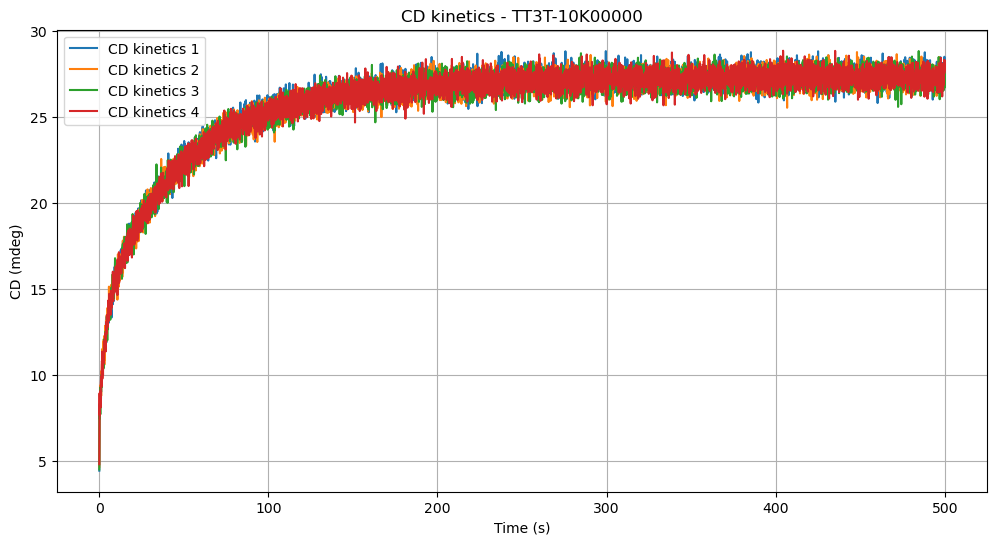

In [17]:
if not os.path.isdir(directory):
    raise FileNotFoundError(f"Data directory not found: {directory!r}. Edit the 'directory' variable in the first cell.")

# List of all CSV files in the directory
all_files = glob.glob(os.path.join(directory, "*.csv"))
if not all_files:
    raise FileNotFoundError(f"No CSV files found in {directory!r}.")

all_dfs = []
metadata = []

for file in all_files:
    try:
        start_index = None
        end_index = None
        date = None
        temperature = None
        pathlength = None
        wavelength = None
        bandwidth = None

        # Pass 1: read the header metadata (date, temperature, path length, wavelength, bandwidth)
        with open(file, 'r') as f:
            lines = f.readlines()
            for i, line in enumerate(lines):
                if "#Date:" in line:
                    date = line.split(":")[1].strip()
                elif "#Temperature:" in line:
                    temperature = line.split(":")[1].strip()
                elif "#Pathlength:" in line:
                    pathlength = line.split(":")[1].strip()
                if "Wavelength" in line and "Bandwidth" in line:
                    parts = line.split(",")
                    for part in parts:
                        if "Wavelength:" in part:
                            wavelength = part.split(":")[1].replace('nm', '').strip()
                        elif "Bandwidth" in part:
                            bandwidth = part.split(":")[1].replace('nm', '').strip()
                    break

        # Print the extracted metadata
        print(f"Metadata of file {file}:")
        print(f"Measurement date: {date}")
        print(f"Temperature: {temperature}")
        print(f"Pathlength: {pathlength} mm")
        print(f"Wavelength: {wavelength} nm")
        print(f"Bandwidth: {bandwidth} nm")

        metadata.append({"File": file, "Measurement date": date, "Temperature": temperature,
                         "Pathlength (mm)": pathlength, "Wavelength (nm)": wavelength, "Bandwidth (nm)": bandwidth})

        # Pass 2: locate the data block of the Chirascan export.
        # The block starts after the "Data:" keyword (first numeric line) and ends at the first empty line;
        # this relies on the exported data containing no missing values.
        start_index = None
        end_index = None

        with open(file, 'r') as f:
            lines = f.readlines()
            for i, line in enumerate(lines):
                if "Data:" in line:
                    start_index = i
                elif start_index is not None and "." in line:
                    if end_index is None:
                        start_index = i
                    end_index = i - 1
                elif start_index is not None and end_index is not None and line.strip() == "":
                    break

        df = pd.read_csv(file, delimiter=',', skiprows=start_index - 1, nrows=end_index - start_index + 2)
        df.rename(columns={"Unnamed: 0": "Time"}, inplace=True)

        df = df.dropna(axis=1, how='all')             # drop columns containing only NaN
        df = df.loc[:, (df != 0).any(axis=0)]         # drop columns containing only zeros (unused repeats)

        if "HV" in df.columns:                        # drop the detector high-voltage column
            df = df.drop(columns="HV")

        df.columns = ["Time"] + [f"CD kinetics {i+1}" for i in range(df.shape[1] - 1)]
        all_dfs.append(df)

    except (OSError, ValueError, TypeError, IndexError, pd.errors.ParserError) as exc:
        raise RuntimeError(
            f"Failed to read {file!r}. Check that it is a Chirascan CSV export "
            f"(metadata header + 'Data:' block). Original error: {exc}"
        ) from exc

    # Visual check of correct loading
    print("\n")
    print("Visual check of correct loading:")
    print("\n")

    print(f"First 5 rows of {file}:")
    print(df.head())
    print("\n")

    print(f"Last 5 rows of {file}:")
    print(df.tail())
    print("\n" + "=" * 50 + "\n")


# Plot the CD kinetics of every file
for idx, df in enumerate(all_dfs):
    plt.figure(figsize=(12, 6))
    for column in df.columns[1:]:
        plt.plot(df.iloc[:, 0], df[column], label=column)

    plt.title(f'CD kinetics - {os.path.basename(all_files[idx]).rsplit(".", 1)[0]}')
    plt.xlabel('Time (s)')
    plt.ylabel('CD (mdeg)')
    plt.legend()
    plt.grid(True)
    plt.show()

## 2. Select, average and trim the kinetic traces

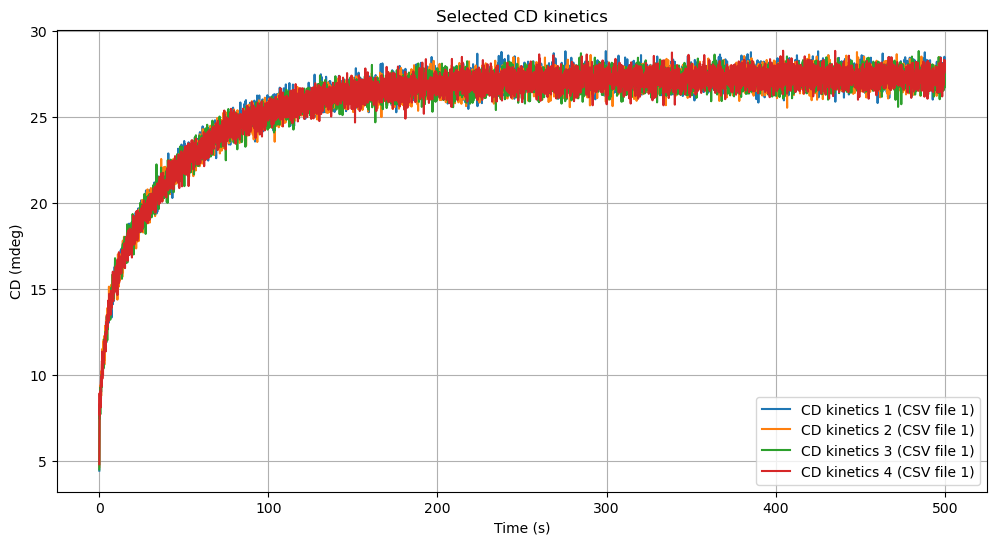

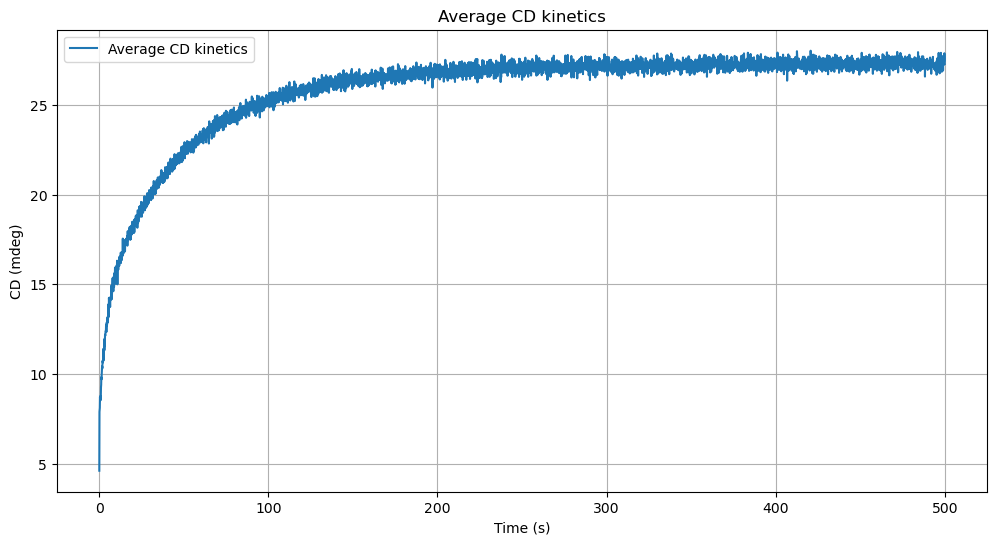

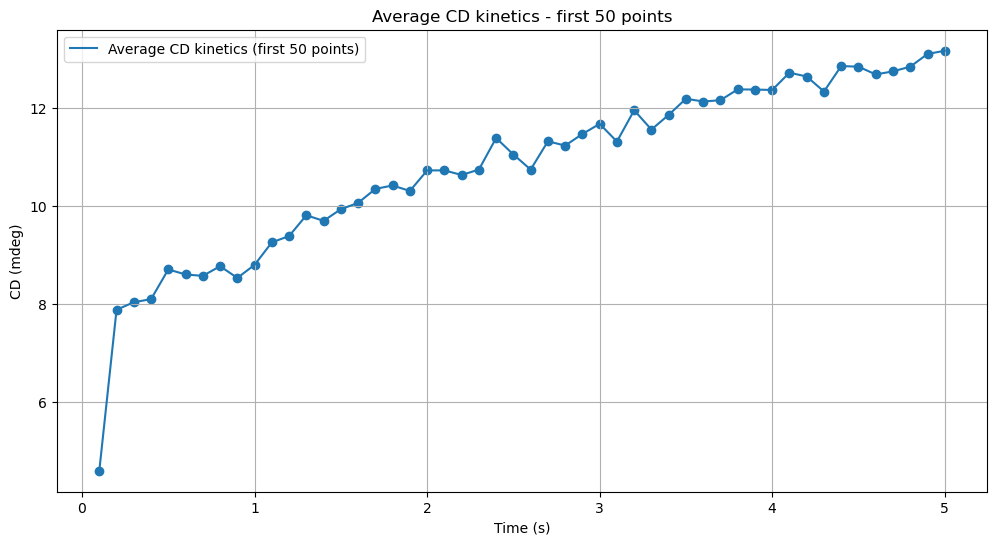

In [18]:
# Select and average the acceptable kinetic traces.
# Each entry is (file index, column name); index 0 = first CSV file, 1 = second CSV file, ...
chosen_columns = [
    (0, "CD kinetics 1"),
    (0, "CD kinetics 2"),
    (0, "CD kinetics 3"),
    (0, "CD kinetics 4")
]

try:
    plt.figure(figsize=(12, 6))
    for index, column in chosen_columns:
        plt.plot(all_dfs[index]["Time"], all_dfs[index][column], label=f"{column} (CSV file {index+1})")

    plt.title('Selected CD kinetics')
    plt.xlabel('Time (s)')
    plt.ylabel('CD (mdeg)')
    plt.legend()
    plt.grid(True)
    plt.show()

    mean_df = pd.DataFrame()
    first_index, first_column = chosen_columns[0]
    mean_df["Time"] = all_dfs[first_index]["Time"]  # the time axis of the first selected trace is used

    # Sum the selected traces in one DataFrame column
    for index, column in chosen_columns:
        if "Average CD kinetics" not in mean_df.columns:
            mean_df["Average CD kinetics"] = all_dfs[index][column]
        else:
            mean_df["Average CD kinetics"] += all_dfs[index][column]

    # Divide by the number of traces to obtain the mean
    mean_df["Average CD kinetics"] /= len(chosen_columns)
except (IndexError, KeyError) as exc:
    raise KeyError(
        f"Invalid entry in 'chosen_columns' ({exc}). Check the file indices (0-based) and the column names "
        f"printed in the loading cell."
    ) from exc

plt.figure(figsize=(12, 6))
plt.plot(mean_df["Time"], mean_df["Average CD kinetics"], label="Average CD kinetics")
plt.title('Average CD kinetics')
plt.xlabel('Time (s)')
plt.ylabel('CD (mdeg)')
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(mean_df["Time"].iloc[:50], mean_df["Average CD kinetics"].iloc[:50], label="Average CD kinetics (first 50 points)")
plt.scatter(mean_df["Time"].iloc[:50], mean_df["Average CD kinetics"].iloc[:50])
plt.title('Average CD kinetics - first 50 points')
plt.xlabel('Time (s)')
plt.ylabel('CD (mdeg)')
plt.legend()
plt.grid(True)
plt.show()

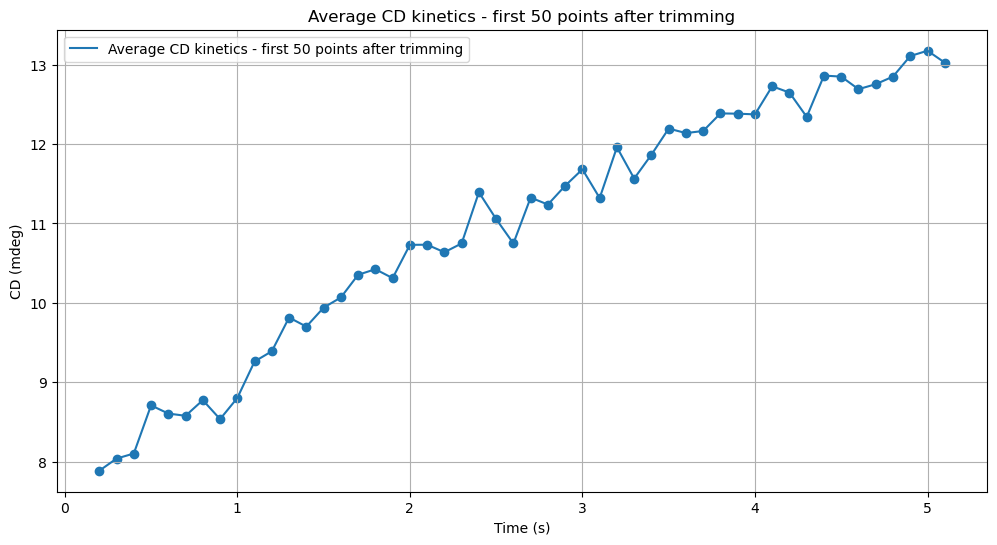

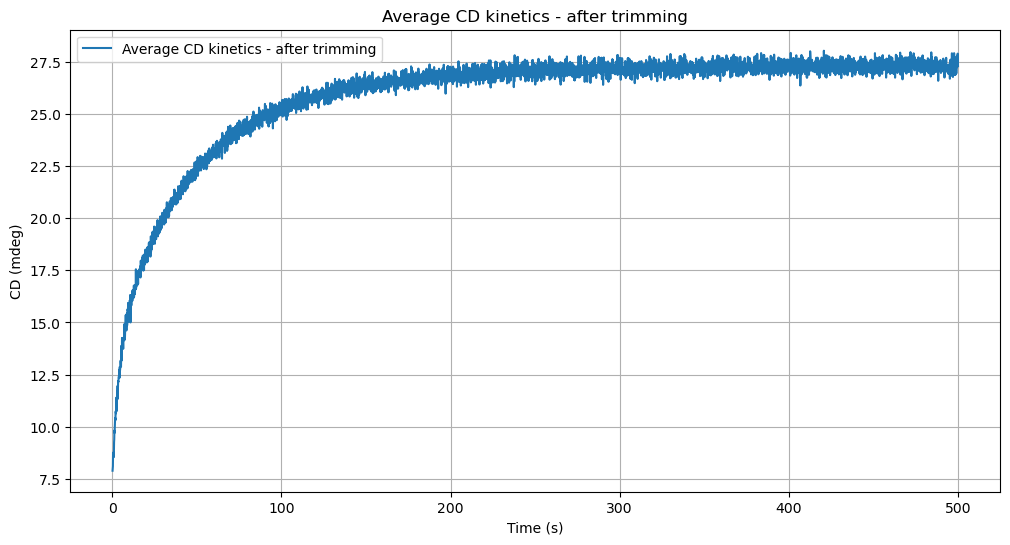

In [19]:
# Number of points to remove from the BEGINNING of the kinetics (removes meaningless data from the instrument dead time)
points_to_remove_from_beginning = 1

# Number of points to remove from the END of the kinetics (0 = keep all)
points_to_remove_from_end = 0

if points_to_remove_from_beginning < 0 or points_to_remove_from_end < 0:
    raise ValueError("The number of points to remove must not be negative.")
if points_to_remove_from_beginning + points_to_remove_from_end >= len(mean_df):
    raise ValueError("Too many points to remove - no data would be left.")

trimmed_df = mean_df.iloc[points_to_remove_from_beginning:len(mean_df) - points_to_remove_from_end]

# Show the first 50 points of the averaged kinetics again after trimming
plt.figure(figsize=(12, 6))
plt.plot(trimmed_df["Time"].iloc[:50], trimmed_df["Average CD kinetics"].iloc[:50], label="Average CD kinetics - first 50 points after trimming")
plt.scatter(trimmed_df["Time"].iloc[:50], trimmed_df["Average CD kinetics"].iloc[:50])
plt.title('Average CD kinetics - first 50 points after trimming')
plt.xlabel('Time (s)')
plt.ylabel('CD (mdeg)')
plt.legend()
plt.grid(True)
plt.show()

# Show the whole averaged kinetics again after trimming
plt.figure(figsize=(12, 6))
plt.plot(trimmed_df["Time"], trimmed_df["Average CD kinetics"], label="Average CD kinetics - after trimming")
plt.title('Average CD kinetics - after trimming')
plt.xlabel('Time (s)')
plt.ylabel('CD (mdeg)')
plt.legend()
plt.grid(True)
plt.show()

## 3. Baseline subtraction and conversion to Δε

Path length used: absorbance 1.0 cm, CD 1.0 cm


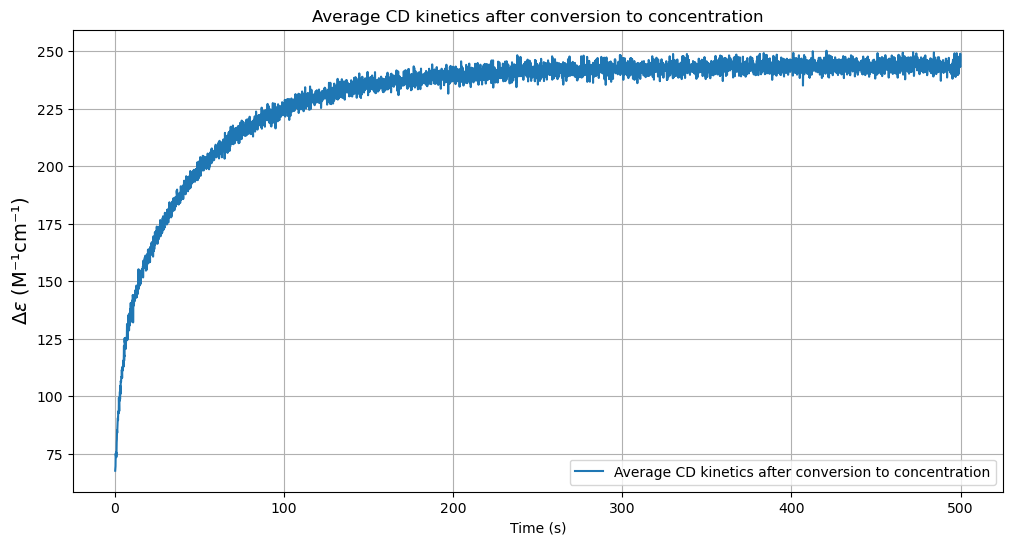

In [20]:
# Subtract the baseline (a single number here) and convert the CD signal from mdeg to molar circular dichroism
# (delta epsilon, M^-1 cm^-1; the concentration is expressed per strand):
#
#     delta_epsilon = theta[mdeg] / (32980 * c * l_CD)
#
# - 32980 converts ellipticity in mdeg to differential absorbance:  theta[mdeg] = 32980 * delta_A.
# - c follows from the absorbance of the UNMIXED solution measured on the Specord:
#   A = epsilon_strand * c * l_abs, with epsilon_strand = sequence_length * extinction_coefficient
#   (extinction_coefficient is the average extinction coefficient per nucleotide, M^-1 cm^-1 nt^-1).
# - 0.5: the absorbance was measured before mixing; the 1:1 mixing in the stopped-flow halves the concentration.
# - l_abs and l_CD are the optical path lengths of the absorbance and of the CD (stopped-flow) measurement; they cancel
#   if they are equal (e.g. both 1 cm), but must be set if they differ (e.g. a 1 mm stopped-flow cell).

# Input variables
sequence_length = 23           # sequence length in nt (TTT - 21, TT3T - 23, T3T3T3 - 27, TT5T - 25, TT4T - 24, TT2T - 22)
extinction_coefficient = 10443 # average extinction coefficient per nucleotide, M^-1 cm^-1 nt^-1 (TTT - 10626, TT3T - 10443, T3T3T3 - 10158, TT5T - 10289, TT4T - 10363, TT2T - 10530, 1/x TT3T 10431)
absorbance = 1.6079            # absorbance of the unmixed solution measured on the Specord spectrophotometer
baseline = 0.42                # baseline: LiOH buffer at the corresponding wavelength (mdeg)

absorbance_pathlength_cm = 1.0 # optical path length of the cuvette used for the absorbance measurement (cm)
cd_pathlength_cm = None        # optical path length of the stopped-flow cell (cm); None = read '#Pathlength:' (mm) from the CSV header

# Path length of the CD measurement
if cd_pathlength_cm is None:
    try:
        header_values_cm = {float(metadata[index]["Pathlength (mm)"]) / 10 for index, _ in chosen_columns}
    except (TypeError, ValueError) as exc:
        raise ValueError("The path length was not found in the CSV header - set 'cd_pathlength_cm' manually.") from exc
    if len(header_values_cm) != 1:
        raise ValueError(f"The selected CSV files have different path lengths in the header ({sorted(header_values_cm)} cm). "
                         f"Select files measured with the same path length.")
    cd_pathlength_used_cm = header_values_cm.pop()
else:
    cd_pathlength_used_cm = cd_pathlength_cm
print(f"Path length used: absorbance {absorbance_pathlength_cm} cm, CD {cd_pathlength_used_cm} cm")

try:
    constant_multiplier = (sequence_length * extinction_coefficient * absorbance_pathlength_cm) / (32980 * 0.5 * absorbance * cd_pathlength_used_cm)
except ZeroDivisionError as exc:
    raise ZeroDivisionError("'absorbance' and the CD path length must be non-zero.") from exc

# Subtract the baseline and multiply by the constant (starts from trimmed_df, so re-running this cell is safe)
kinetics_df = trimmed_df.copy()
kinetics_df["Average CD kinetics"] = (trimmed_df["Average CD kinetics"] - baseline) * constant_multiplier

# Snapshot of the inputs used for this conversion (written to the Excel export)
analysis_inputs = {
    "Selected kinetics": [f"{column} (CSV file {index + 1})" for index, column in chosen_columns],
    "Points removed from the beginning": points_to_remove_from_beginning,
    "Points removed from the end": points_to_remove_from_end,
    "Sequence length (nt)": sequence_length,
    "Extinction coefficient (M^-1 cm^-1 nt^-1)": extinction_coefficient,
    "Absorbance of the unmixed solution": absorbance,
    "Path length of the absorbance measurement (cm)": absorbance_pathlength_cm,
    "Path length of the CD measurement (cm)": cd_pathlength_used_cm,
    "Baseline (mdeg)": baseline,
    "Conversion factor (mdeg -> delta epsilon)": constant_multiplier,
}

# Plot again to check the applied corrections
plt.figure(figsize=(12, 6))
plt.plot(kinetics_df["Time"], kinetics_df["Average CD kinetics"], label="Average CD kinetics after conversion to concentration")
plt.title('Average CD kinetics after conversion to concentration')
plt.xlabel('Time (s)')
plt.ylabel(r'$\Delta\varepsilon$ (M⁻¹cm⁻¹)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

## 4. Models and fitting machinery
This cell defines the five models, a generic `fit_model()` function and the helper functions.
Run it once; then fit any model with `fit_model("<name>")`. Every fit is stored in `fit_results`.

In [21]:
# ---------------------------------------------------------------------------
# Model functions
# ---------------------------------------------------------------------------
def one_phase_association(t, A, k, y0):
    """Single exponential rise: A*(1-exp(-k*t)) + y0."""
    return A * (1 - np.exp(-k * t)) + y0


def two_phase_association(t, A1, k1, A2, k2, y0):
    """Sum of two exponential rises: A1*(1-exp(-k1*t)) + A2*(1-exp(-k2*t)) + y0."""
    return A1 * (1 - np.exp(-k1 * t)) + A2 * (1 - np.exp(-k2 * t)) + y0


def three_phase_association(t, A1, k1, A2, k2, A3, k3, y0):
    """Sum of three exponential rises plus offset y0."""
    return A1 * (1 - np.exp(-k1 * t)) + A2 * (1 - np.exp(-k2 * t)) + A3 * (1 - np.exp(-k3 * t)) + y0


def one_phase_decay(t, y0, asymptota, k):
    """Single exponential decay: (y0 - asymptota)*exp(-k*t) + asymptota."""
    return (y0 - asymptota) * np.exp(-k * t) + asymptota


def two_phase_decay(t, A1, k1, A2, k2, asymptota):
    """Sum of two exponential decays plus asymptote: A1*exp(-k1*t) + A2*exp(-k2*t) + asymptota."""
    return A1 * np.exp(-k1 * t) + A2 * np.exp(-k2 * t) + asymptota


# ---------------------------------------------------------------------------
# Model specifications: initial guesses (p0), bounds and plot settings.
# Lower bounds: amplitudes and rate constants >= 0; offsets (y0 / asymptote) are unbounded
# (only the rate constant k is bounded in the one-phase decay).
# Fits can be sensitive to p0 - edit p0 here if a fit does not converge (see also CHECK_STARTS).
# ---------------------------------------------------------------------------
_DELTA_EPS = r'$\Delta\varepsilon$ (M⁻¹cm⁻¹)'

MODELS = {
    "one phase association": dict(
        func=one_phase_association, names=["A", "k", "y0"], amplitudes=["A"], rates=["k"], kind="association",
        p0=(30, 0.1, 25), lower=[0, 0, -np.inf], upper=[np.inf, np.inf, np.inf],
        fit_title="CD folding kinetics - one exponential model", res_title="Residuals analysis - one exponential model",
        ylabel=_DELTA_EPS, ylabel_size=14, font_fit=None, data_color=None, res_font=None),
    "two phase association": dict(
        func=two_phase_association, names=["A1", "k1", "A2", "k2", "y0"], amplitudes=["A1", "A2"], rates=["k1", "k2"],
        kind="association", p0=(700, 0.6, 30, 0.05, 25), lower=[0, 0, 0, 0, -np.inf], upper=[np.inf] * 5,
        fit_title="CD folding kinetics - two exponential model", res_title="Residuals analysis - two exponential model",
        ylabel=_DELTA_EPS + " 265 nm", ylabel_size=14, font_fit=15, data_color=None, res_font=12),
    "three phase association": dict(
        func=three_phase_association, names=["A1", "k1", "A2", "k2", "A3", "k3", "y0"],
        amplitudes=["A1", "A2", "A3"], rates=["k1", "k2", "k3"], kind="association",
        p0=(100, 0.08, 50, 0.02, 20, 0.005, 70), lower=[0, 0, 0, 0, 0, 0, -np.inf], upper=[np.inf] * 7,
        fit_title="CD folding kinetics - three exponential model", res_title="Residuals analysis - three exponential model",
        ylabel=_DELTA_EPS, ylabel_size=14, font_fit=12, data_color=None, res_font=12),
    "one phase decay": dict(
        func=one_phase_decay, names=["y0", "asymptota", "k"], amplitudes=[], rates=["k"], kind="decay_one",
        p0=(20, 100, 0.003), lower=[-np.inf, -np.inf, 0], upper=[np.inf, np.inf, np.inf],
        fit_title="CD folding kinetics - one exponential model", res_title="Residual Plot CD data - one exponential model",
        ylabel=_DELTA_EPS + " 297 nm", ylabel_size=None, font_fit=15, data_color=None, res_font=None),
    "two phase decay": dict(
        func=two_phase_decay, names=["A1", "k1", "A2", "k2", "asymptota"], amplitudes=["A1", "A2"], rates=["k1", "k2"],
        kind="decay_two", p0=(10, 0.1, 5, 0.005, 30), lower=[0, 0, 0, 0, -np.inf], upper=[np.inf] * 5,
        fit_title="Fit of averaged CD kinetics - two phase decay", res_title="Residual Plot CD data - two phase decay",
        ylabel=_DELTA_EPS, ylabel_size=14, font_fit=None, data_color=None, res_font=None),
}

# Storage of results (survives re-running fit cells; overwritten only by refitting the same model)
fit_results = globals().get("fit_results", {})
f_test_results = globals().get("f_test_results", {})


# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------
def get_kinetics():
    """Return (time, signal) arrays of the converted kinetics (kinetics_df)."""
    try:
        return kinetics_df["Time"].values, kinetics_df["Average CD kinetics"].values
    except NameError as exc:
        raise NameError("'kinetics_df' is not defined - run the loading, averaging and conversion cells first.") from exc


def data_fingerprint(df):
    """Short hash of the analysed data; used to detect fits that do not belong to the current data."""
    arr = np.ascontiguousarray(df[["Time", "Average CD kinetics"]].to_numpy(dtype=float))
    return hashlib.sha256(arr.tobytes()).hexdigest()[:16]


def fit_curve(func, x_data, y_data, p0, lower, upper, label):
    """curve_fit wrapper with a readable error message."""
    try:
        return curve_fit(func, x_data, y_data, p0=p0, bounds=(lower, upper), maxfev=10000)
    except (RuntimeError, ValueError) as exc:
        raise RuntimeError(
            f"{label} fit failed (no convergence or invalid input). Try different initial guesses (p0) or bounds. "
            f"Original error: {exc}"
        ) from exc


def figure_png():
    """Return the current matplotlib figure as PNG bytes (kept in memory; no temporary files)."""
    buf = io.BytesIO()
    try:
        plt.savefig(buf, format="png")
        return buf.getvalue()
    except (OSError, ValueError) as exc:
        print(f"WARNING: could not render the figure for the Excel export: {exc}")
        return None


def multistart_check(spec, x_data, y_data, ss_res_main, n_starts, seed=0):
    """Refit from randomly perturbed p0 (log-normal, sigma = 0.5) and report whether a lower minimum exists."""
    if n_starts <= 0:
        return "not performed"
    rng = np.random.default_rng(seed)
    p0 = np.asarray(spec["p0"], dtype=float)
    ss_list = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for _ in range(n_starts):
            trial = p0 * np.exp(rng.normal(0.0, 0.5, size=p0.size))
            try:
                trial_params, _ = curve_fit(spec["func"], x_data, y_data, p0=trial,
                                            bounds=(spec["lower"], spec["upper"]), maxfev=10000)
            except (RuntimeError, ValueError):
                continue
            ss_list.append(np.sum((y_data - spec["func"](x_data, *trial_params)) ** 2))
    if not ss_list:
        return f"0/{n_starts} perturbed starts converged - the fit may be very sensitive to p0"
    ss_arr = np.array(ss_list)
    same = int(np.sum(np.abs(ss_arr - ss_res_main) <= 1e-6 * ss_res_main))
    text = f"{len(ss_arr)}/{n_starts} perturbed starts converged, {same} reached the same minimum"
    if ss_arr.min() < ss_res_main * (1 - 1e-6):
        text += (f"; WARNING: a LOWER minimum was found (SSR {ss_arr.min():.6g} vs {ss_res_main:.6g}) - "
                 f"consider changing p0 for this model")
    else:
        text += "; no lower minimum found"
    return text


def quality_warnings(spec, params, cis, covariance):
    """Simple sanity checks of a fit; returns a list of warning strings."""
    found = []
    if not np.all(np.isfinite(covariance)):
        found.append("covariance matrix is not finite - confidence intervals are undefined (poorly determined parameters)")
    for i, name in enumerate(spec["names"]):
        lower = spec["lower"][i]
        if np.isfinite(lower) and abs(params[i] - lower) < 1e-8:
            found.append(f"{name} is at its lower bound ({lower}) - the phase may not be present in the data")
    for name in spec["rates"]:
        i = spec["names"].index(name)
        if np.isfinite(cis[0][i]) and cis[0][i] <= 0:
            found.append(f"95 % CI of {name} includes zero - the rate constant is poorly determined")
    return found


# ---------------------------------------------------------------------------
# Generic model fit
# ---------------------------------------------------------------------------
def fit_model(model_name, show_plots=True, check_starts=None):
    """
    Fit one model to kinetics_df, print the results, plot the fit and residuals and store everything in
    fit_results[model_name]. Returns the result dictionary.
    """
    if model_name not in MODELS:
        raise KeyError(f"Unknown model {model_name!r}. Available models: {list(MODELS)}")
    spec = MODELS[model_name]
    func = spec["func"]
    names = spec["names"]
    check_starts = CHECK_STARTS if check_starts is None else check_starts

    # Get the data
    x_data, y_data = get_kinetics()

    # Fit
    params, covariance = fit_curve(func, x_data, y_data, spec["p0"], spec["lower"], spec["upper"], model_name.capitalize())
    par = dict(zip(names, params))

    # 95 % confidence intervals of the fitted parameters (t-distribution, from the covariance matrix)
    alpha = 0.05
    n = len(y_data)
    p = len(params)
    dof = max(0, n - p)  # degrees of freedom
    t_val = stats.t.ppf(1.0 - alpha / 2.0, dof)
    std_errs = np.sqrt(np.diag(covariance))
    cis = [params - t_val * std_errs, params + t_val * std_errs]
    ci = {name: (cis[0][i], cis[1][i]) for i, name in enumerate(names)}

    # Tau (1/k) and half-life (ln2/k); their CIs follow from the CI of k (monotonic transformation)
    tau, half_life, tau_ci, half_life_ci = {}, {}, {}, {}
    for r in spec["rates"]:
        k = par[r]
        tau[r] = 1 / k
        half_life[r] = np.log(2) / k
        k_lo, k_hi = ci[r]
        if np.isfinite(k_lo) and k_lo > 0:
            tau_ci[r] = (1 / k_hi, 1 / k_lo)
            half_life_ci[r] = (np.log(2) / k_hi, np.log(2) / k_lo)
        else:
            tau_ci[r] = half_life_ci[r] = None

    # y0 and asymptote (value at t -> infinity)
    if spec["kind"] == "association":
        y0, y0_ci = par["y0"], ci["y0"]
        asymptote = sum([par[a] for a in spec["amplitudes"]] + [y0])
        asymptote_ci = None                      # a CI of the summed asymptote is not reported
    elif spec["kind"] == "decay_one":
        y0, y0_ci = par["y0"], ci["y0"]
        asymptote, asymptote_ci = par["asymptota"], ci["asymptota"]
    else:  # decay_two: y0 = f(0), standard error by the delta method: SE(y0) = sqrt(J @ Cov @ J^T)
        y0 = func(0, *params)
        derivatives = np.array([1.0, 0.0, 1.0, 0.0, 1.0])  # d f(0) / d(A1, k1, A2, k2, asymptota)
        se_y0 = np.sqrt(derivatives @ covariance @ derivatives.T)
        y0_ci = (y0 - t_val * se_y0, y0 + t_val * se_y0)
        asymptote, asymptote_ci = par["asymptota"], ci["asymptota"]

    # Residuals
    fitted = func(x_data, *params)
    residuals = y_data - fitted

    # Goodness-of-fit statistics
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    r_squared = 1 - (ss_res / ss_tot)
    rmsd = np.sqrt(ss_res / len(y_data))
    n = len(y_data)
    p = len(params)
    aic = n * np.log(ss_res / n) + 2 * p
    bic = n * np.log(ss_res / n) + p * np.log(n)

    # Likelihood-based AIC / BIC (Gaussian errors, sigma^2 estimated with n - p degrees of freedom)
    sigma2_hat = ss_res / (n - p)
    log_likelihood = -0.5 * n * np.log(2 * np.pi * sigma2_hat) - (ss_res / (2 * sigma2_hat))
    aic2 = -2 * log_likelihood + 2 * p
    bic2 = -2 * log_likelihood + p * np.log(n)

    # Residual autocorrelation: Durbin-Watson (~2 = uncorrelated; << 2 = positive autocorrelation) and lag-1 correlation.
    # Strong autocorrelation means the parameter CIs above are probably too narrow.
    durbin_watson = np.sum(np.diff(residuals) ** 2) / np.sum(residuals**2)
    lag1_autocorr = np.sum(residuals[1:] * residuals[:-1]) / np.sum(residuals**2)

    # Equation with fitted parameters (signs written as "+ x" / "- x")
    def add(v):
        return f"+ {v:.4f}" if v >= 0 else f"- {abs(v):.4f}"

    def sub(v):
        return f"- {v:.4f}" if v >= 0 else f"+ {abs(v):.4f}"

    if spec["kind"] == "association":
        terms = " + ".join(f"{par[a]:.4f} * (1 - exp(-{par[r]:.4f} * t))" for a, r in zip(spec["amplitudes"], spec["rates"]))
        equation = f"y = {terms} {add(par['y0'])}"
    elif spec["kind"] == "decay_one":
        equation = f"y = ({par['y0']:.4f} {sub(par['asymptota'])}) * exp(-{par['k']:.4f} * t) {add(par['asymptota'])}"
    else:
        terms = " + ".join(f"{par[a]:.4f} * exp(-{par[r]:.4f} * t)" for a, r in zip(spec["amplitudes"], spec["rates"]))
        equation = f"y = {terms} {add(par['asymptota'])}"

    # Rows for the Excel export: (label, value, CI lower, CI upper, unit)
    unit_signal = "M^-1 cm^-1"
    rows = [("y0", y0, y0_ci[0], y0_ci[1], unit_signal)]
    for a in spec["amplitudes"]:
        rows.append((a, par[a], ci[a][0], ci[a][1], unit_signal))
    for r in spec["rates"]:
        rows.append((r, par[r], ci[r][0], ci[r][1], "s^-1"))
    rows.append(("Asymptote", asymptote, *(asymptote_ci if asymptote_ci else (None, None)), unit_signal))
    for r in spec["rates"]:
        suffix = r[1:]
        for label, value, interval in (("Tau" + suffix, tau[r], tau_ci[r]), ("Half Life" + suffix, half_life[r], half_life_ci[r])):
            rows.append((label, value, *(interval if interval else (None, None)), "s"))

    # Print fit parameters (value and 95 % CI)
    print(f"=== {model_name} ===")
    for label, value, lo, hi, unit in rows:
        fmt = ".5f" if unit == "s^-1" else ".3f"
        if lo is None:
            print(f"{label} = {value:{fmt}} {unit}")
        else:
            print(f"{label} = {value:{fmt}} ({lo:{fmt}}, {hi:{fmt}}) {unit}")
    print()
    print(f"R^2: {r_squared:.3f}")
    print(f"RMSD: {rmsd:.3f}")
    print(f"AIC: {aic:.3f}")
    print(f"BIC: {bic:.3f}")
    print(f"AIC (Gaussian log-likelihood): {aic2:.3f}")
    print(f"BIC (Gaussian log-likelihood): {bic2:.3f}")
    print(f"Durbin-Watson: {durbin_watson:.3f} (lag-1 residual autocorrelation: {lag1_autocorr:.3f})")
    print()
    print(f"{model_name.capitalize()} equation:")
    print(equation)

    # Sanity checks
    found = quality_warnings(spec, params, cis, covariance)
    multistart = multistart_check(spec, x_data, y_data, ss_res, check_starts)
    print()
    print(f"Multi-start check: {multistart}")
    for message in found:
        print(f"WARNING: {message}")

    # Plots (font sizes are set locally and do not leak into other figures)
    figures = {}
    smoothed_residuals = None
    if show_plots:
        fit_rc = {"font.size": spec["font_fit"]} if spec["font_fit"] else {}
        with plt.rc_context(fit_rc):
            plt.figure(figsize=(12, 6))
            data_kw = {"color": spec["data_color"]} if spec["data_color"] else {}
            plt.plot(x_data, y_data, 'o', markersize=3, label='Data', **data_kw)
            plt.plot(x_data, fitted, '-', label='Fit', color='red')
            plt.title(spec["fit_title"])
            plt.xlabel('Time (s)')
            if spec["ylabel_size"]:
                plt.ylabel(spec["ylabel"], fontsize=spec["ylabel_size"])
            else:
                plt.ylabel(spec["ylabel"])
            plt.legend()
            plt.grid(True)
            figures["fit"] = figure_png()
            plt.show()

        # Savitzky-Golay filter for smoothing the residuals
        try:
            smoothed_residuals = savgol_filter(residuals, window_length=51, polyorder=3)
        except ValueError as exc:
            raise ValueError(
                f"Savitzky-Golay smoothing failed (window_length=51 requires at least 51 data points; got {len(residuals)}). "
                f"Reduce window_length. Original error: {exc}"
            ) from exc

        res_rc = {"font.size": spec["res_font"]} if spec["res_font"] else {}
        with plt.rc_context(res_rc):
            plt.figure(figsize=(12, 6))
            plt.plot(x_data, residuals, 'o', markersize=3, label='Original Residuals', color='green')
            plt.plot(x_data, smoothed_residuals, '-', label='Smoothed Residuals', color='blue')
            plt.axhline(0, color='red', linestyle='--')
            plt.title(spec["res_title"])
            plt.xlabel('Time (s)')
            plt.ylabel('Residuals')
            plt.grid(True)
            plt.legend()
            figures["residuals"] = figure_png()
            plt.show()

    result = dict(
        model=model_name, names=names, params=params, covariance=covariance, cis=cis, par=par, ci=ci,
        tau=tau, half_life=half_life, tau_ci=tau_ci, half_life_ci=half_life_ci,
        y0=y0, y0_ci=y0_ci, asymptote=asymptote, asymptote_ci=asymptote_ci,
        residuals=residuals, smoothed_residuals=smoothed_residuals, fitted=fitted,
        ss_res=ss_res, r_squared=r_squared, rmsd=rmsd, aic=aic, bic=bic, aic2=aic2, bic2=bic2,
        durbin_watson=durbin_watson, lag1_autocorr=lag1_autocorr, n_points=n, n_params=p,
        equation=equation, rows=rows, warnings=found, multistart=multistart, figures=figures,
        data_fingerprint=data_fingerprint(kinetics_df),
    )
    fit_results[model_name] = result
    return result


# ---------------------------------------------------------------------------
# F-test for nested models (extra-sum-of-squares test)
# ---------------------------------------------------------------------------
def run_nested_f_test(simple, complex_, p0_simple, p0_complex, short=("Single", "Two")):
    """
    Compare a simpler model with a more complex one that contains it (e.g. 1 vs 2 or 2 vs 3 exponentials).
    The starting values are passed explicitly (they can differ from the ones in MODELS).
    """
    x_data, y_data = get_kinetics()
    fits = {}
    for name, p0 in ((simple, p0_simple), (complex_, p0_complex)):
        spec = MODELS[name]
        params, covariance = fit_curve(spec["func"], x_data, y_data, p0, spec["lower"], spec["upper"], name.capitalize())
        residuals = y_data - spec["func"](x_data, *params)
        fits[name] = dict(params=params, residuals=residuals, ss_res=np.sum(residuals**2), n_params=len(params))

    n = len(y_data)
    s, c = fits[simple], fits[complex_]
    df_res_simple = n - s["n_params"]
    df_res_complex = n - c["n_params"]

    # F statistic for the extra-sum-of-squares test and its p-value
    F_stat = ((s["ss_res"] - c["ss_res"]) / (c["n_params"] - s["n_params"])) / (c["ss_res"] / df_res_complex)
    p_value = stats.f.sf(F_stat, c["n_params"] - s["n_params"], df_res_complex)

    print(f"SS_res ({simple}): {s['ss_res']}")
    print(f"SS_res ({complex_}): {c['ss_res']}")
    print(f"Degrees of freedom ({simple}): {df_res_simple}")
    print(f"Degrees of freedom ({complex_}): {df_res_complex}")
    print(f"F-statistic: {F_stat}")
    print(f"P-value: {p_value}" + ("  (underflow: p < 1e-300)" if p_value == 0 else ""))

    # Plot the fits
    plt.figure(figsize=(12, 6))
    plt.plot(x_data, y_data, 'o', markersize=3, label='Data', color='blue')
    plt.plot(x_data, MODELS[simple]["func"](x_data, *s["params"]), '-', label=f'{short[0]} Exponential Fit', color='red')
    plt.plot(x_data, MODELS[complex_]["func"](x_data, *c["params"]), '--', label=f'{short[1]} Exponential Fit', color='green')
    plt.title('Fit of averaged CD kinetics')
    plt.xlabel('Time (s)')
    plt.ylabel(_DELTA_EPS, fontsize=14)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot the residuals
    plt.figure(figsize=(12, 6))
    plt.plot(x_data, s["residuals"], 'o', markersize=3, label=f'Residuals {short[0]}', color='red')
    plt.plot(x_data, c["residuals"], 'x', markersize=3, label=f'Residuals {short[1]}', color='green')
    plt.axhline(0, color='black', linestyle='--')
    plt.title('Residuals')
    plt.xlabel('Time (s)')
    plt.ylabel('Residuals')
    plt.legend()
    plt.grid(True)
    plt.show()

    result = dict(simple=simple, complex=complex_, F_stat=F_stat, p_value=p_value,
                  df_numerator=c["n_params"] - s["n_params"], df_residual=df_res_complex,
                  ss_res_simple=s["ss_res"], ss_res_complex=c["ss_res"],
                  data_fingerprint=data_fingerprint(kinetics_df))
    f_test_results[(simple, complex_)] = result
    return result

## 5. Model fits
Each cell fits one model and stores the result in `fit_results`; run any of them, in any order. The results do not
overwrite each other. Interpretation guide for model comparison:
- R²: an increase of 0.01 or more may be considered significant.
- RMSD: a decrease of 10 % or more may be significant.
- AIC / BIC: a decrease of 2 points may be considered evidence for a better model; a decrease of 6 or more points is
  considered strong evidence.
- Durbin-Watson far below 2: the residuals are autocorrelated (systematic misfit or correlated noise) and the confidence
  intervals are probably too narrow.

### 5a. One-phase association

=== one phase association ===
y0 = 105.670 (104.997, 106.344) M^-1 cm^-1
A = 136.517 (135.855, 137.179) M^-1 cm^-1
k = 0.02235 (0.02218, 0.02252) s^-1
Asymptote = 242.187 M^-1 cm^-1
Tau = 44.745 (44.402, 45.094) s
Half Life = 31.015 (30.777, 31.257) s

R^2: 0.982
RMSD: 3.546
AIC: 12663.071
BIC: 12682.622
AIC (Gaussian log-likelihood): 26849.619
BIC (Gaussian log-likelihood): 26869.170
Durbin-Watson: 0.745 (lag-1 residual autocorrelation: 0.616)

One phase association equation:
y = 136.5169 * (1 - exp(-0.0223 * t)) + 105.6702

Multi-start check: 5/5 perturbed starts converged, 5 reached the same minimum; no lower minimum found


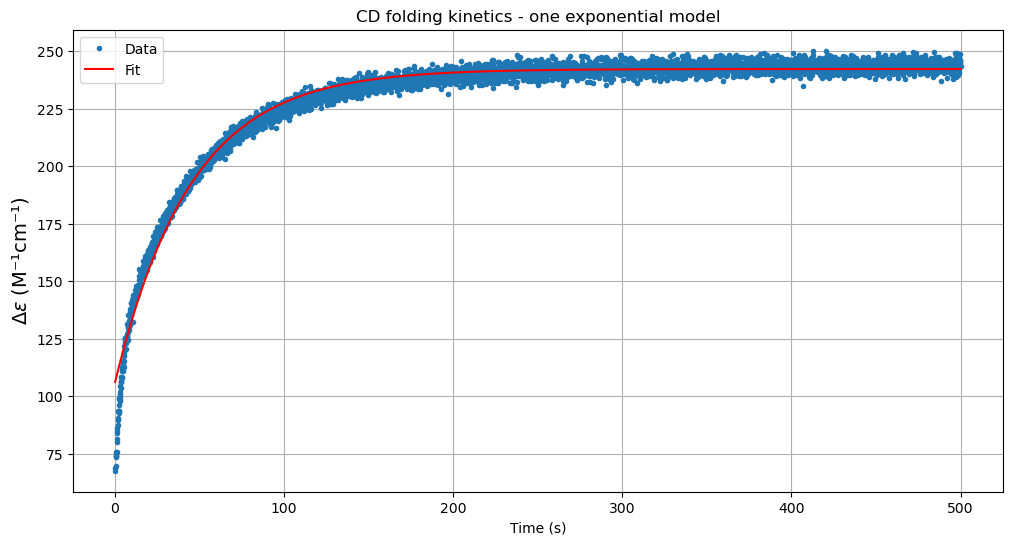

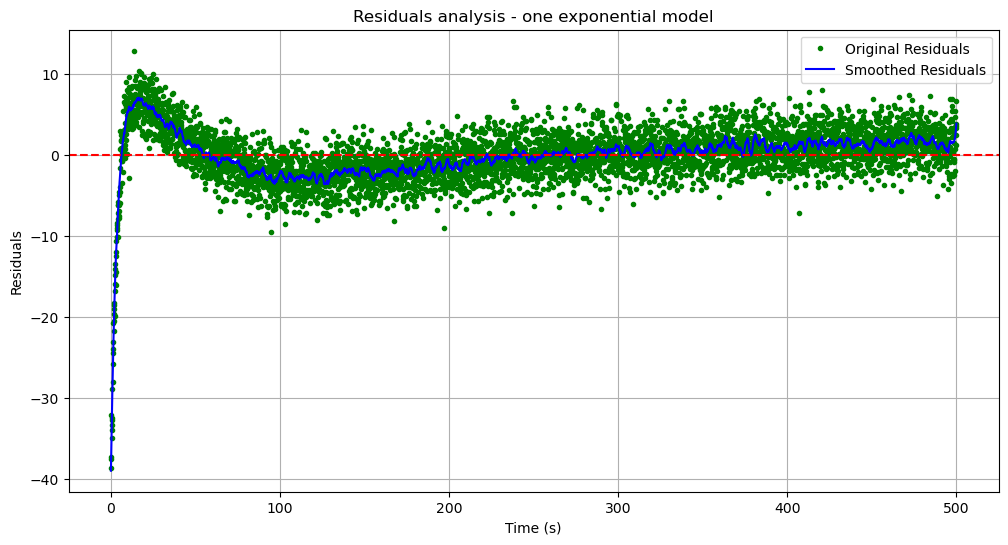

In [22]:
result = fit_model("one phase association")

### 5b. Two-phase association

=== two phase association ===
y0 = 68.982 (67.695, 70.269) M^-1 cm^-1
A1 = 61.047 (59.724, 62.370) M^-1 cm^-1
A2 = 113.025 (112.132, 113.917) M^-1 cm^-1
k1 = 0.17191 (0.16454, 0.17929) s^-1
k2 = 0.01825 (0.01809, 0.01841) s^-1
Asymptote = 243.054 M^-1 cm^-1
Tau1 = 5.817 (5.578, 6.078) s
Half Life1 = 4.032 (3.866, 4.213) s
Tau2 = 54.791 (54.324, 55.267) s
Half Life2 = 37.978 (37.654, 38.308) s

R^2: 0.993
RMSD: 2.241
AIC: 8078.118
BIC: 8110.703
AIC (Gaussian log-likelihood): 22264.668
BIC (Gaussian log-likelihood): 22297.253
Durbin-Watson: 1.864 (lag-1 residual autocorrelation: 0.068)

Two phase association equation:
y = 61.0470 * (1 - exp(-0.1719 * t)) + 113.0247 * (1 - exp(-0.0183 * t)) + 68.9822

Multi-start check: 5/5 perturbed starts converged, 5 reached the same minimum; no lower minimum found


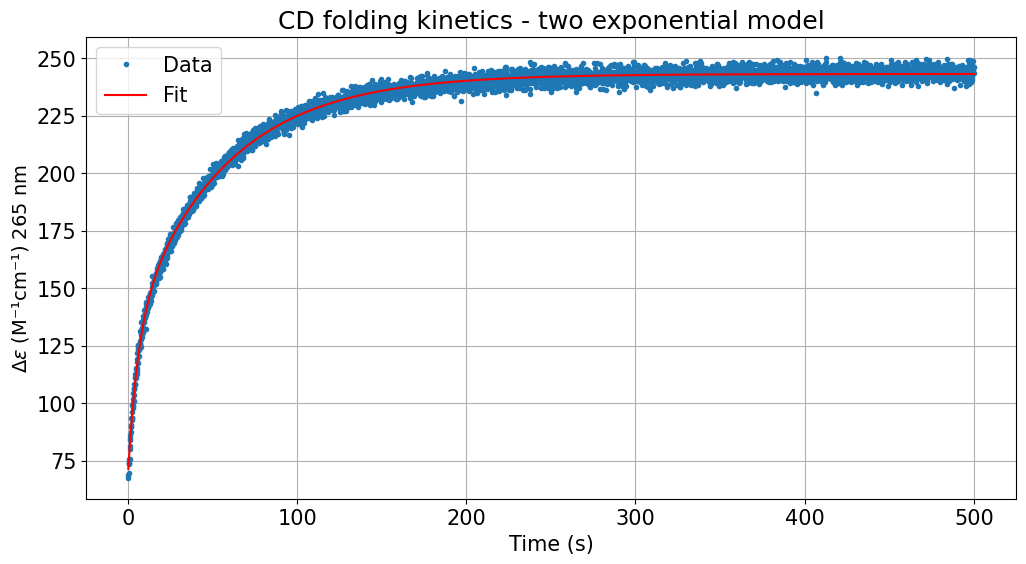

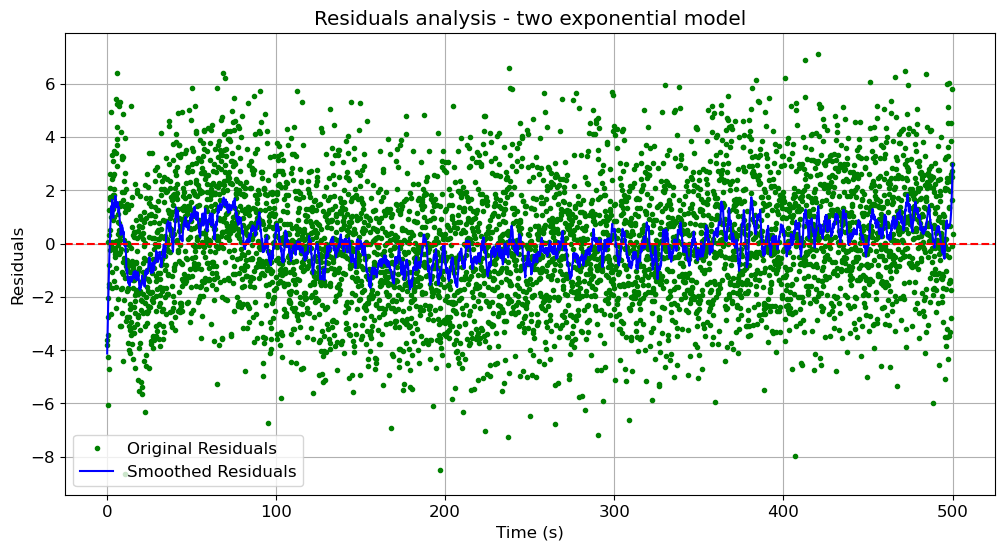

In [23]:
result = fit_model("two phase association")

### 5c. Three-phase association

=== three phase association ===
y0 = 64.641 (63.059, 66.223) M^-1 cm^-1
A1 = 53.357 (51.387, 55.327) M^-1 cm^-1
A2 = 83.260 (69.764, 96.755) M^-1 cm^-1
A3 = 42.505 (27.829, 57.181) M^-1 cm^-1
k1 = 0.24983 (0.23193, 0.26773) s^-1
k2 = 0.02694 (0.02413, 0.02974) s^-1
k3 = 0.01178 (0.01015, 0.01342) s^-1
Asymptote = 243.762 M^-1 cm^-1
Tau1 = 4.003 (3.735, 4.312) s
Half Life1 = 2.774 (2.589, 2.989) s
Tau2 = 37.125 (33.622, 41.443) s
Half Life2 = 25.733 (23.305, 28.726) s
Tau3 = 84.868 (74.517, 98.560) s
Half Life3 = 58.826 (51.651, 68.316) s

R^2: 0.993
RMSD: 2.165
AIC: 7734.511
BIC: 7780.130
AIC (Gaussian log-likelihood): 21921.064
BIC (Gaussian log-likelihood): 21966.682
Durbin-Watson: 1.998 (lag-1 residual autocorrelation: 0.001)

Three phase association equation:
y = 53.3568 * (1 - exp(-0.2498 * t)) + 83.2596 * (1 - exp(-0.0269 * t)) + 42.5047 * (1 - exp(-0.0118 * t)) + 64.6409

Multi-start check: 4/5 perturbed starts converged, 4 reached the same minimum; no lower minimum found


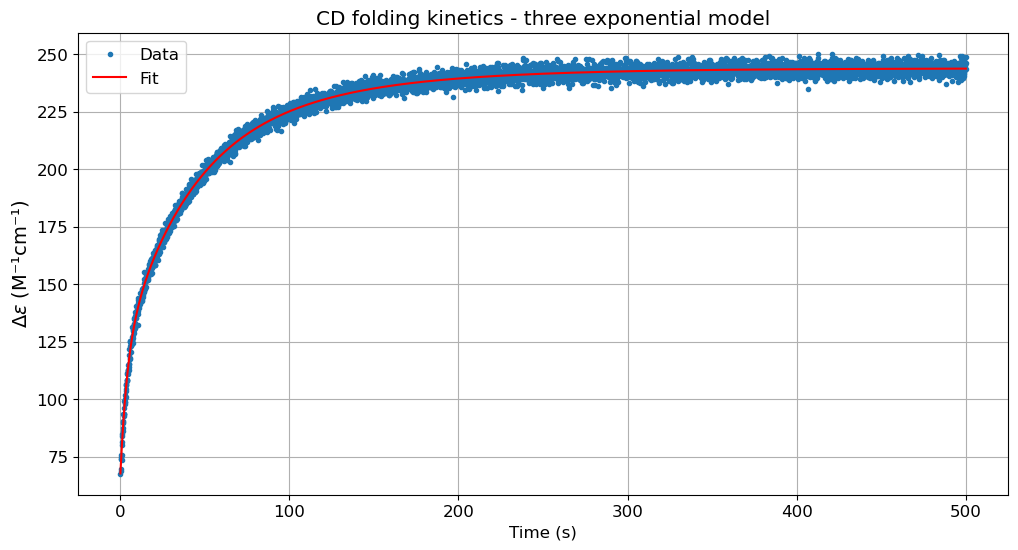

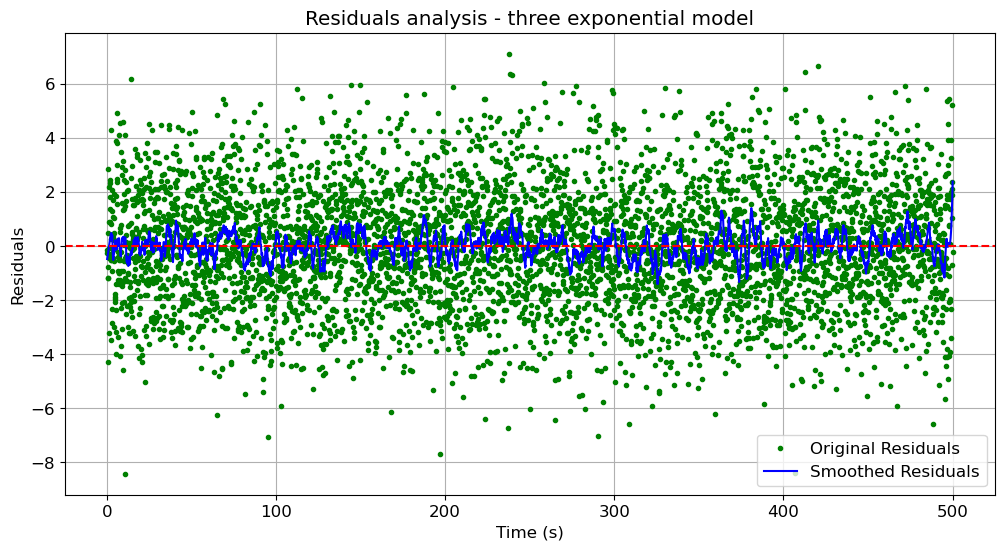

In [24]:
result = fit_model("three phase association")

### 5d. One-phase decay

=== one phase decay ===
y0 = 105.670 (104.997, 106.344) M^-1 cm^-1
k = 0.02235 (0.02218, 0.02252) s^-1
Asymptote = 242.187 (242.064, 242.310) M^-1 cm^-1
Tau = 44.745 (44.402, 45.094) s
Half Life = 31.015 (30.777, 31.257) s

R^2: 0.982
RMSD: 3.546
AIC: 12663.071
BIC: 12682.622
AIC (Gaussian log-likelihood): 26849.619
BIC (Gaussian log-likelihood): 26869.170
Durbin-Watson: 0.745 (lag-1 residual autocorrelation: 0.616)

One phase decay equation:
y = (105.6702 - 242.1872) * exp(-0.0223 * t) + 242.1872

Multi-start check: 5/5 perturbed starts converged, 5 reached the same minimum; no lower minimum found


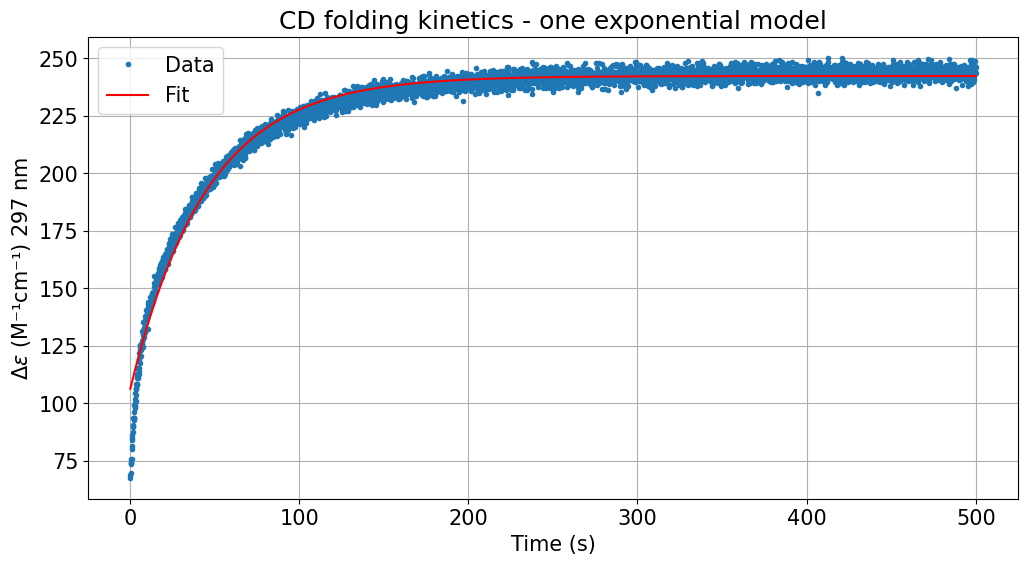

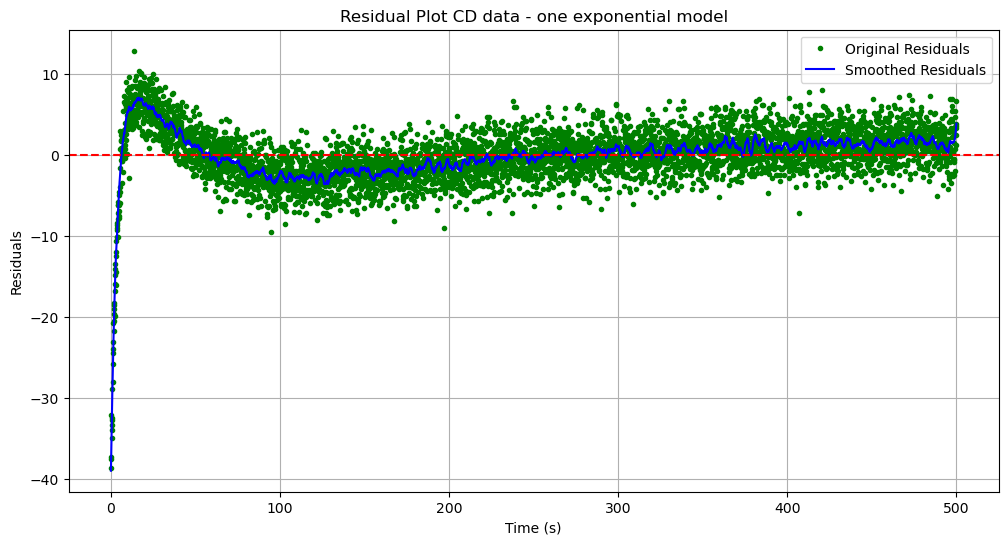

In [25]:
result = fit_model("one phase decay")

### 5e. Two-phase decay

=== two phase decay ===
y0 = 234.009 (232.548, 235.470) M^-1 cm^-1
A1 = 4.000 (4.000, 4.000) M^-1 cm^-1
A2 = 0.000 (-949931.975, 949931.975) M^-1 cm^-1
k1 = 163.86506 (163.86506, 163.86506) s^-1
k2 = 0.00000 (-31545.17816, 31545.17816) s^-1
Asymptote = 230.009 (-949701.984, 950162.002) M^-1 cm^-1
Tau1 = 0.006 (0.006, 0.006) s
Half Life1 = 0.004 (0.004, 0.004) s
Tau2 = 17944391.750 s
Half Life2 = 12438104.548 s

R^2: -0.000
RMSD: 26.321
AIC: 32706.951
BIC: 32739.536
AIC (Gaussian log-likelihood): 46893.501
BIC (Gaussian log-likelihood): 46926.086
Durbin-Watson: 0.014 (lag-1 residual autocorrelation: 0.989)

Two phase decay equation:
y = 3.9999 * exp(-163.8651 * t) + 0.0000 * exp(-0.0000 * t) + 230.0088

Multi-start check: 5/5 perturbed starts converged, 5 reached the same minimum; no lower minimum found


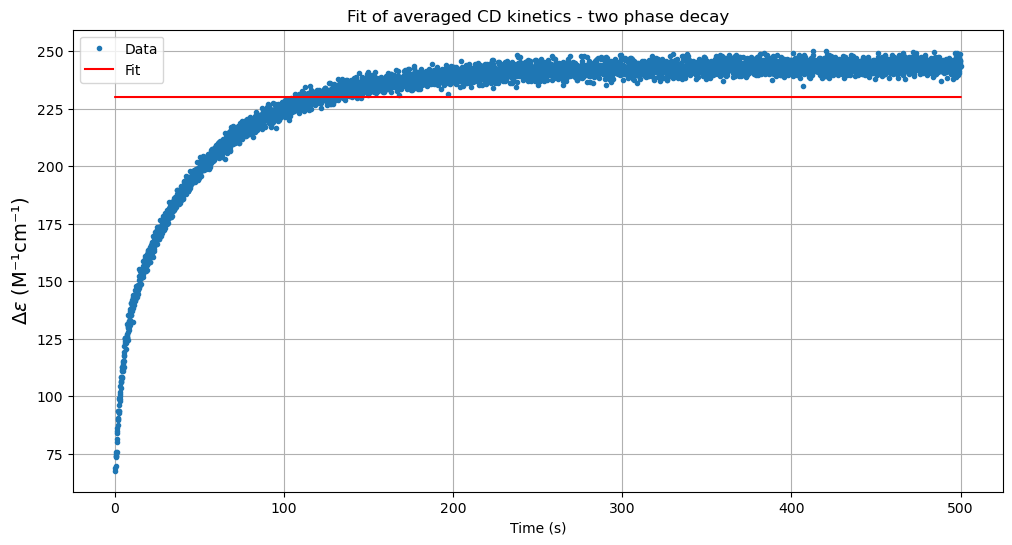

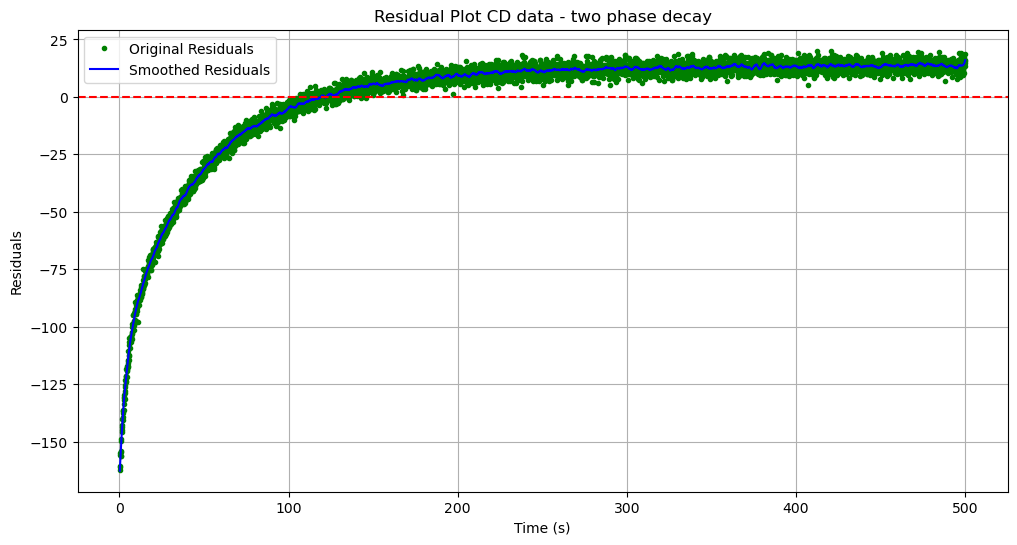

In [26]:
result = fit_model("two phase decay")

## 6. F-test for nested model comparison
The starting values are given explicitly, exactly as they were used in the original analysis (they differ from the `p0`
in `MODELS`).

SS_res (one phase association): 62875.61729496879
SS_res (two phase association): 25107.94512941477
Degrees of freedom (one phase association): 4996
Degrees of freedom (two phase association): 4994
F-statistic: 3756.017344760962
P-value: 0.0  (underflow: p < 1e-300)


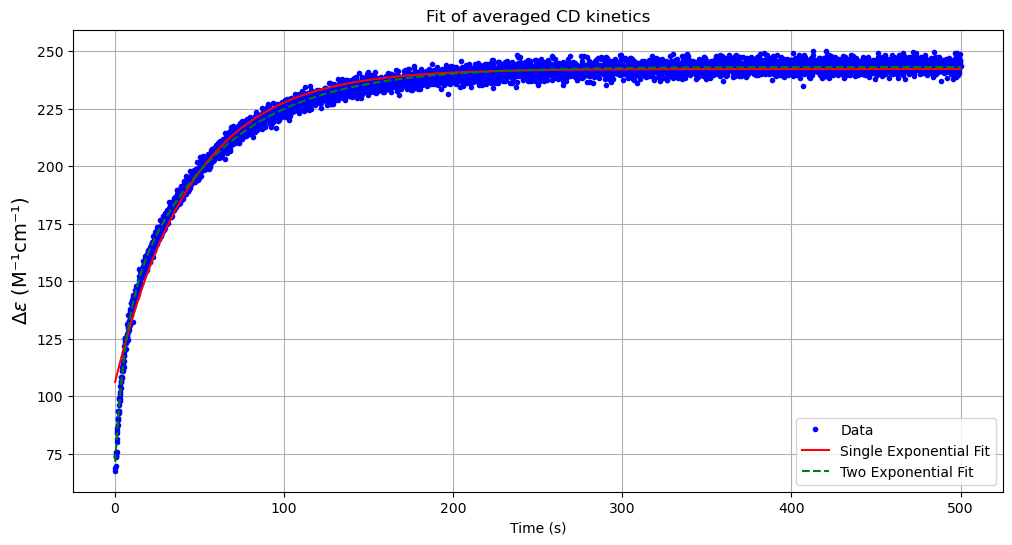

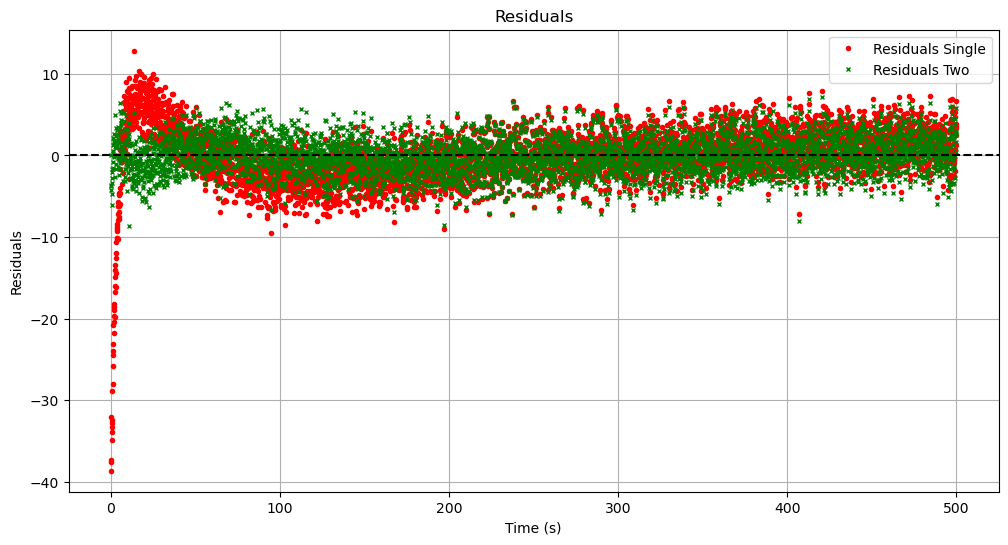

In [27]:
### F-test: 1 vs 2 exponentials
f_1_vs_2 = run_nested_f_test(
    "one phase association", "two phase association",
    p0_simple=(30, 0.1, 25), p0_complex=(20, 0.1, 100, 0.05, 25),
    short=("Single", "Two"))

SS_res (two phase association): 25107.945133571877
SS_res (three phase association): 23421.37368592256
Degrees of freedom (two phase association): 4994
Degrees of freedom (three phase association): 4992
F-statistic: 179.73678187214637
P-value: 4.205097103827071e-76


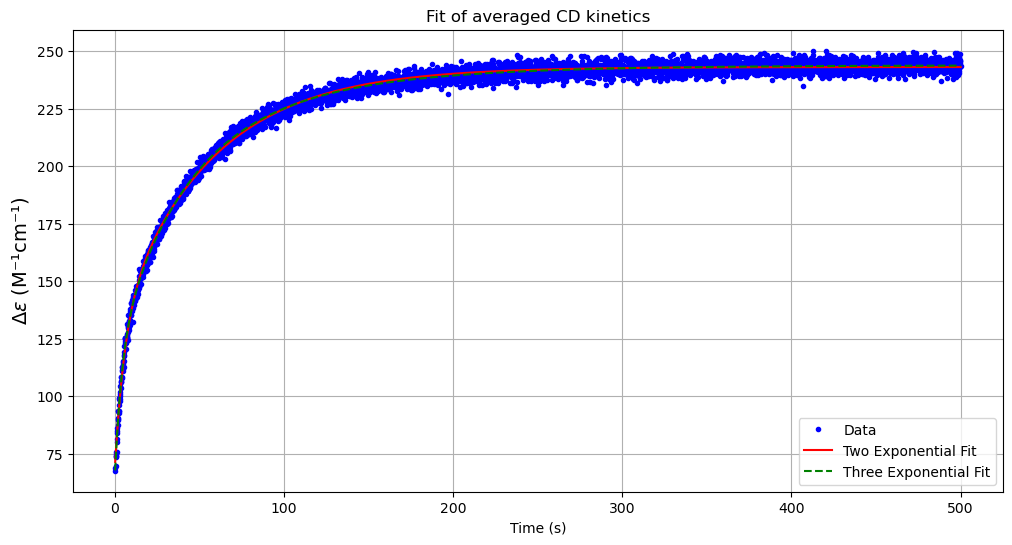

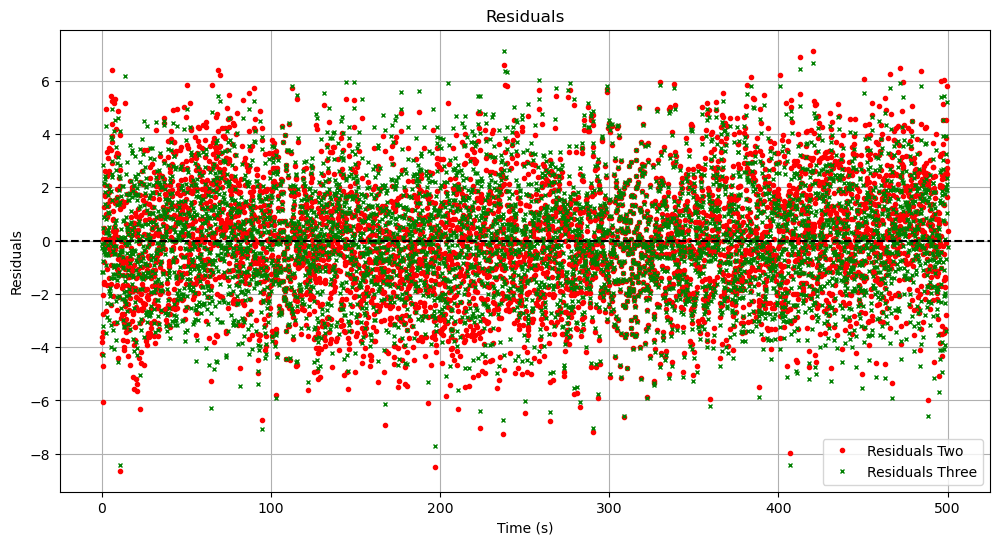

In [28]:
### F-test: 2 vs 3 exponentials
f_2_vs_3 = run_nested_f_test(
    "two phase association", "three phase association",
    p0_simple=(20, 0.01, 10, 0.005, 25), p0_complex=(100, 0.150, 50, 0.02, 20, 0.005, 70),
    short=("Two", "Three"))

## 7. Export results to Excel (single sheet)
Set `MODEL_TO_EXPORT` to the name of a fitted model and run the cell. Everything is written to one sheet, `Results`:
the summary (metadata of every CSV file, analysis inputs, fit results with 95 % CI, goodness of fit, equation, F-tests,
software versions) and the two figures on the left; the data tables (original data of every CSV file, then the converted
kinetics with the fit and the residuals) side by side on the right. Works for any number of CSV files.

**Available model names** (copy one of them into `MODEL_TO_EXPORT`; only models that were fitted above can be exported):
- `one phase association`
- `two phase association`
- `three phase association`
- `one phase decay`
- `two phase decay`

In [29]:
# Model to export - one of (copy the name):
#   "one phase association" | "two phase association" | "three phase association" | "one phase decay" | "two phase decay"
# It must have been fitted above (i.e. be a key of fit_results).
MODEL_TO_EXPORT = "three phase association"

DATA_START_COL = 9  # first column (J) of the data tables; the summary and figures occupy columns A-H


def export_results(model_name, output_filename=None):
    """Write the summary, figures and data tables to a single 'Results' sheet of an Excel workbook."""
    if model_name not in fit_results:
        raise KeyError(f"No stored fit for {model_name!r}. Fitted models: {list(fit_results)}. Run the fit cell first.")
    fit = fit_results[model_name]
    if fit["data_fingerprint"] != data_fingerprint(kinetics_df):
        raise RuntimeError(
            f"The stored fit of {model_name!r} was made on different data than the current 'kinetics_df' "
            f"(the selection, trimming or conversion was changed afterwards). Re-run the fit cell."
        )
    if output_filename is None:
        output_filename = os.path.join(directory, "results CD.xlsx")

    try:
        import xlsxwriter
        with pd.ExcelWriter(output_filename, engine="xlsxwriter") as writer:
            workbook = writer.book
            ws = workbook.add_worksheet("Results")
            writer.sheets["Results"] = ws

            bold = workbook.add_format({"bold": True})
            title = workbook.add_format({"bold": True, "font_size": 14})
            header = workbook.add_format({"bold": True, "bottom": 1})
            num4 = workbook.add_format({"num_format": "0.0000"})
            num5 = workbook.add_format({"num_format": "0.00000"})
            sci = workbook.add_format({"num_format": "0.00E+00"})

            ws.set_column(0, 0, 36)
            ws.set_column(1, 3, 14)
            ws.set_column(4, 4, 16)
            ws.set_column(5, 5, 14)

            r = 0
            ws.write(r, 0, "Stopped-flow CD kinetic analysis", title); r += 1
            ws.write(r, 0, "Exported on:"); ws.write(r, 1, datetime.now().strftime("%Y-%m-%d %H:%M:%S")); r += 2

            # --- Metadata of every CSV file ---
            ws.write(r, 0, "Metadata of the CSV files", bold); r += 1
            columns = ["File", "Measurement date", "Temperature", "Pathlength (mm)", "Wavelength (nm)", "Bandwidth (nm)"]
            for c, name in enumerate(columns):
                ws.write(r, c, name, header)
            r += 1
            for item in metadata:
                for c, name in enumerate(columns):
                    value = os.path.basename(item[name]) if name == "File" else item[name]
                    ws.write(r, c, value)
                r += 1
            r += 1

            # --- Analysis inputs ---
            ws.write(r, 0, "Analysis inputs", bold); r += 1
            for key, value in analysis_inputs.items():
                ws.write(r, 0, key)
                if isinstance(value, list):
                    ws.write(r, 1, "; ".join(value))
                elif isinstance(value, (int, float, np.integer, np.floating)):
                    ws.write_number(r, 1, float(value))
                else:
                    ws.write(r, 1, str(value))
                r += 1
            r += 1

            # --- Fit results ---
            ws.write(r, 0, f"Fit results - {model_name}", bold); r += 1
            for c, name in enumerate(["Parameter", "Value", "95 % CI lower", "95 % CI upper", "Unit"]):
                ws.write(r, c, name, header)
            r += 1
            for label, value, lo, hi, unit in fit["rows"]:
                fmt = num5 if unit == "s^-1" else num4
                ws.write(r, 0, label)
                ws.write_number(r, 1, float(value), fmt)
                if lo is not None:
                    ws.write_number(r, 2, float(lo), fmt)
                    ws.write_number(r, 3, float(hi), fmt)
                ws.write(r, 4, unit)
                r += 1
            r += 1

            ws.write(r, 0, "Goodness of fit", bold); r += 1
            for label, value in (("R^2", fit["r_squared"]), ("RMSD", fit["rmsd"]), ("AIC", fit["aic"]), ("BIC", fit["bic"]),
                                 ("Durbin-Watson", fit["durbin_watson"]), ("Lag-1 residual autocorrelation", fit["lag1_autocorr"]),
                                 ("Number of points", fit["n_points"]), ("Number of parameters", fit["n_params"])):
                ws.write(r, 0, label); ws.write_number(r, 1, float(value), num4); r += 1
            ws.write(r, 0, "Equation"); ws.write(r, 1, fit["equation"]); r += 1
            ws.write(r, 0, "Multi-start check"); ws.write(r, 1, fit["multistart"]); r += 1
            for message in fit["warnings"]:
                ws.write(r, 0, "Fit warning"); ws.write(r, 1, message); r += 1
            r += 1

            # --- F-tests of nested models (only those made on the current data) ---
            current = [t for t in f_test_results.values() if t["data_fingerprint"] == data_fingerprint(kinetics_df)]
            if current:
                ws.write(r, 0, "F-tests of nested models", bold); r += 1
                for c, name in enumerate(["Comparison", "F", "p-value", "df numerator", "df residual"]):
                    ws.write(r, c, name, header)
                r += 1
                for t in current:
                    ws.write(r, 0, f"{t['simple']} vs {t['complex']}")
                    ws.write_number(r, 1, float(t["F_stat"]), num4)
                    if t["p_value"] == 0:
                        ws.write(r, 2, "< 1e-300")
                    else:
                        ws.write_number(r, 2, float(t["p_value"]), sci)
                    ws.write_number(r, 3, t["df_numerator"])
                    ws.write_number(r, 4, t["df_residual"])
                    r += 1
                r += 1

            # --- Software versions ---
            ws.write(r, 0, "Software", bold); r += 1
            for name, version in (("Analysis script version", SCRIPT_VERSION), ("Python", platform.python_version()),
                                  ("numpy", np.__version__), ("scipy", scipy.__version__), ("pandas", pd.__version__),
                                  ("matplotlib", matplotlib.__version__), ("xlsxwriter", xlsxwriter.__version__)):
                ws.write(r, 0, name); ws.write(r, 1, version); r += 1
            r += 1

            # --- Figures (kept in memory, no temporary files) ---
            for key in ("fit", "residuals"):
                png = fit["figures"].get(key)
                if png is None:
                    continue
                ws.insert_image(r, 0, f"{key}.png", {"image_data": io.BytesIO(png), "x_scale": 0.7, "y_scale": 0.7})
                r += 23

            # --- Data tables, side by side starting at DATA_START_COL ---
            col = DATA_START_COL
            for item, df in zip(metadata, all_dfs):
                out = df.rename(columns={c: (f"{c} (mdeg)" if c != "Time" else "Time (s)") for c in df.columns})
                ws.write(0, col, f"Original data - {os.path.basename(item['File'])}", bold)
                out.to_excel(writer, sheet_name="Results", startrow=1, startcol=col, index=False)
                col += out.shape[1] + 1

            converted = pd.DataFrame({
                "Time (s)": kinetics_df["Time"].values,
                "Average CD kinetics (delta epsilon, M^-1 cm^-1)": kinetics_df["Average CD kinetics"].values,
                f"Fit ({model_name})": fit["fitted"],
                "Residuals": fit["residuals"],
            })
            ws.write(0, col, "Converted kinetics with fit", bold)
            converted.to_excel(writer, sheet_name="Results", startrow=1, startcol=col, index=False)

    except PermissionError as exc:
        raise PermissionError(f"Cannot write {output_filename!r}. Close the file if it is open in Excel and re-run.") from exc
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError("The 'xlsxwriter' package is required for the Excel export (pip install xlsxwriter).") from exc

    print(f"Data saved to {output_filename}")
    return output_filename


export_results(MODEL_TO_EXPORT)

Data saved to example\results CD.xlsx


'example\\results CD.xlsx'